# My great microscope helper code
This code helps you to choose the correct excitation filter for a given wavelength of light (in nm) in a fluorescence microscope!

There are four .txt files which contain the pairs of values for wavelength in nm and transmission (a relative value from 0 to 1) for four different excitation filters.

This code loads the files and stores this information for each filter. You can then input the wavelength you want to use in your microscope and it will tell you which filter to use!

It's really great and I hope you enjoy using it :-)

## Part 1: Load the information about the excitation filters

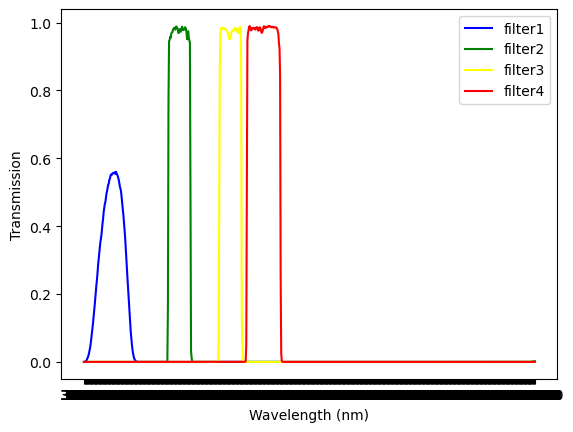

In [54]:
import matplotlib.pyplot as plt
# open each filter file and read in wavelength/transmission values
filter_1 = open('AT350-50-ex.txt', 'r')
lines_1 = filter_1.readlines()
filter_1.close()

filter_2 = open('ET470-40-ex.txt', 'r')
lines_2 = filter_2.readlines()
filter_2.close()

filter_3 = open('ET560-40-ex.txt', 'r')
lines_3 = filter_3.readlines()
filter_3.close()

filter_4 = open('ET620-60-x.txt', 'r')
lines_4 = filter_4.readlines()
filter_4.close()

# separate the wavelengths and transmissions into separate lists
w_1 = []; T_1 = []; w_2 = []; T_2 = []; w_3 = []; T_3 = []; w_4 = []; T_4 = []

for i in range(len(lines_1)):
    # example format of a line: 'WAVELENGTH\tTRANSMISSION\n'
    # e.g. '300.00\t9.9999999392253E-9\n'
    
    # filter 1
    line_1 = lines_1[i]
    line = line_1.split('\t')
    w = line[0]
    w_1.append(w)
    T = float(line[1])
    T_1.append(T)
    
    # filter 2
    line_2 = lines_2[i]
    line = line_2.split('\t')
    w = line[0]
    w_2.append(w)
    T = float(line[1])
    T_2.append(T)
    
    # filter 3
    line_3 = lines_3[i]
    line = line_3.split('\t')
    w = line[0]
    w_3.append(w)
    T = float(line[1])
    T_3.append(T)
    
    # filter 4
    line_4 = lines_4[i]
    line = line_4.split('\t')
    w = line[0]
    w_4.append(w)
    T = float(line[1])
    T_4.append(T)
    
    
# plot the transmission spectra of our filters

plt.plot(w_1, T_1, 'blue',w_2,T_2,'green',w_3,T_3,'yellow',w_4,T_4,'red') 
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.legend(['filter1','filter2','filter3','filter4'])





## Part 2: Decide which filter to choose for a given wavelength

In [62]:
my_wavelength = float(input("What wavelength excitation do you need for your fluorophore? "))
T_min = float(input("What is the minimum transmission you require? "))

# find the minimum and maximum wavelengths that we have for all filters
min_w = float(max(min(w_1), min(w_2), min(w_3), min(w_4)))
max_w = float(min(max(w_1), max(w_2), max(w_3), max(w_4)))

# find filter with highest transmission value for given wavelength
if my_wavelength < min_w or my_wavelength > max_w:
    print('Your wavelength is out of bounds for the filter spectra!')
elif T_min < 0.0 or T_min > 1.0:
    print('User provided an impossible transmission value!') 
else:
    # filter 1 values
    for i in range(w_1):
        if w_1[i] == my_wavelength:
            t1 = T_1[i]
    # filter 2 values
    for i in range(w_2):
        if w_2[i] == my_wavelength:
            t2 = T_2[i]
    # filter 3 values
    for i in range(w_3):
        if w_3[i] == my_wavelength:
            t3 = T_3[i]
    # filter 4 values
    for i in range(w_4):
        if w_4[i] == my_wavelength:
            t4 = T_4[i]
            
    if t_1 < T_min and t_2 < T_min and t_3 < T_min and t_4 < T_min:
        print("No good filters at this wavelength :-(")
    elif t_1 > t_2 and t_1 > t_3 and t_1 > t_4:
        print("Use filter number 1!")
    elif t_2 > t_3 and t_2 > t_4:
        print("Use filter number 2!")
    elif t_3 > t_4:
        print("Use filter number 3!")
    else:
        print("Use filter number 4!")

What wavelength excitation do you need for your fluorophore?  6
What is the minimum transmission you require?  3


Your wavelength is out of bounds for the filter spectra!
